In [1]:
import warnings

warnings.filterwarnings('ignore', message='.*Setting the shape.*') 

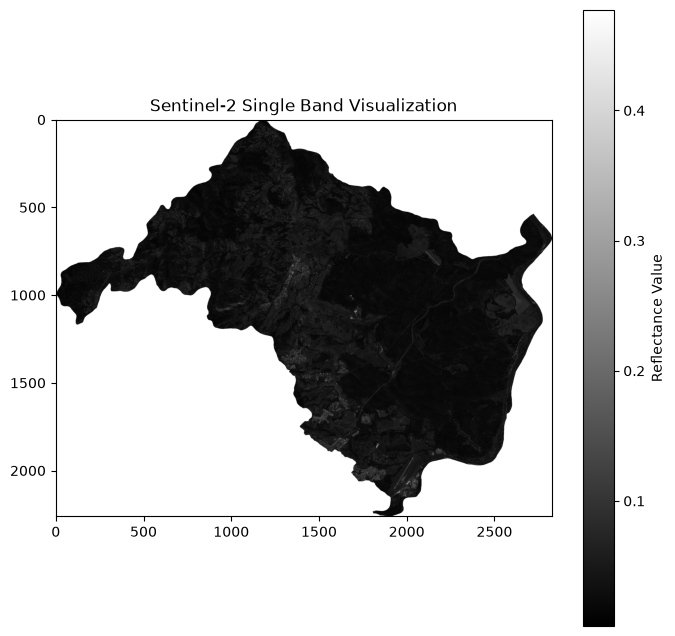

In [2]:
import rasterio
from matplotlib import pyplot as plt

# Open the Sentinel-2 single-band TIFF file
file_path = "../data/S2_Santana_do_Paraiso_2019_Seco.tif"

with rasterio.open(file_path) as src:
    # Read the first band array
    band_data = src.read(1)
    
    # Plot the band using a specific colormap (like 'gray' or 'viridis')
    plt.figure(figsize=(8, 8))
    plt.imshow(band_data, cmap='gray')
    plt.title("Sentinel-2 Single Band Visualization")
    plt.colorbar(label="Reflectance Value")
    plt.show()


In [3]:
import rasterio

file_path = "../data/S2_Santana_do_Paraiso_2019_Seco.tif"

with rasterio.open(file_path) as src:
    print(f"Number of bands: {src.count}")
    print(f"Image dimensions: {src.width}x{src.height}")
    print(f"Data type: {src.dtypes[0]}")

    for i in range(1, src.count + 1):
        print(f"Band {i}: {src.descriptions[i-1]}")


Number of bands: 10
Image dimensions: 2827x2262
Data type: float32
Band 1: B2
Band 2: B3
Band 3: B4
Band 4: B8
Band 5: B5
Band 6: B6
Band 7: B7
Band 8: B8A
Band 9: B11
Band 10: B12


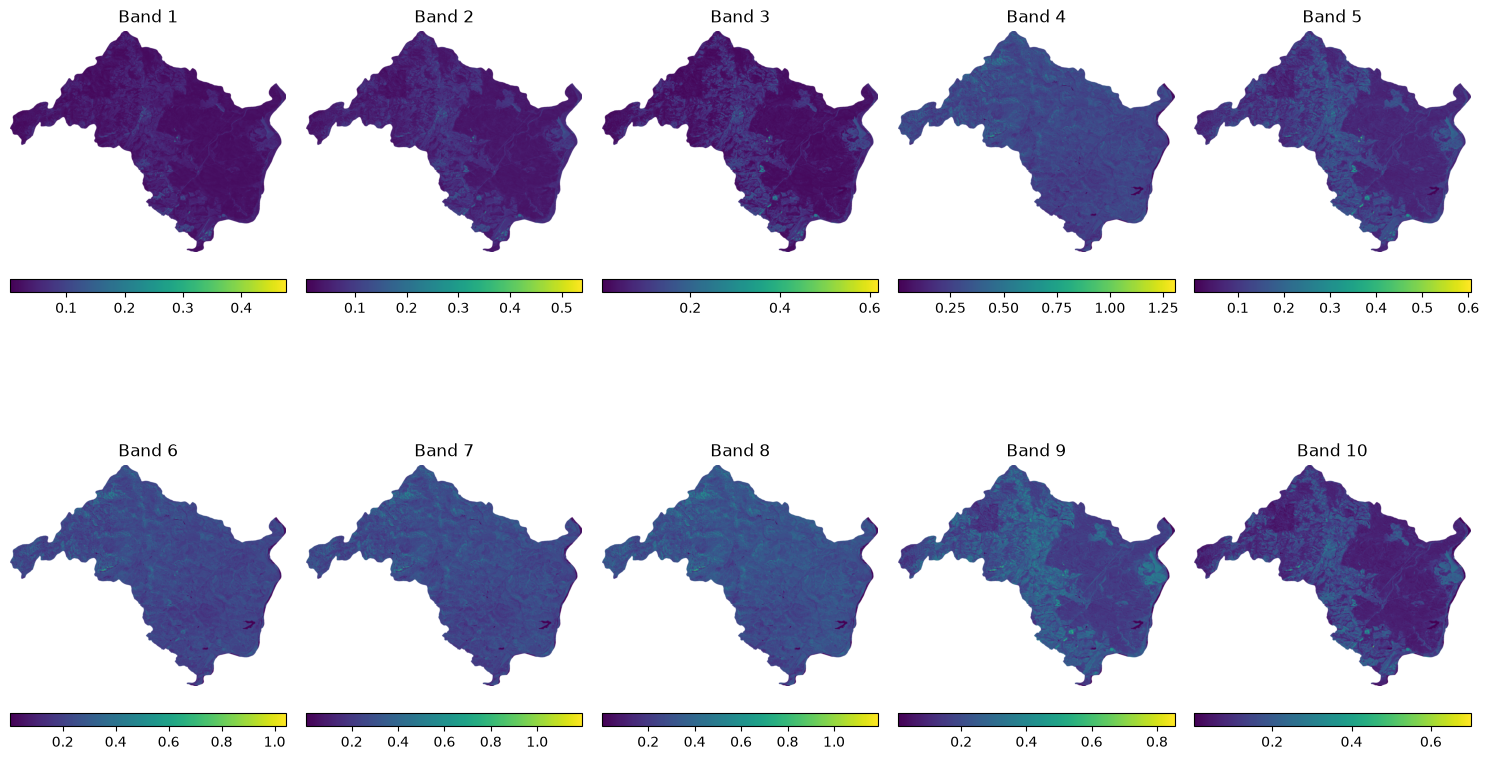

In [4]:
import rasterio
import matplotlib.pyplot as plt
import math

file_path = "../data/S2_Santana_do_Paraiso_2019_Seco.tif"

with rasterio.open(file_path) as src:
    num_bands = src.count
    
    cols = 5
    rows = math.ceil(num_bands / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Flatten to easily iterate with a single index
    
    for i in range(num_bands):
        # Rasterio bands are 1-indexed (Band 1, Band 2, etc.)
        band_index = i + 1 
        band_data = src.read(band_index)
        
        ax = axes[i]
        im = ax.imshow(band_data, cmap='viridis')
        ax.set_title(f"Band {band_index}")
        ax.axis('off')
        
        # Optional: add a colorbar to each subplot
        fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)
        
    for j in range(num_bands, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()


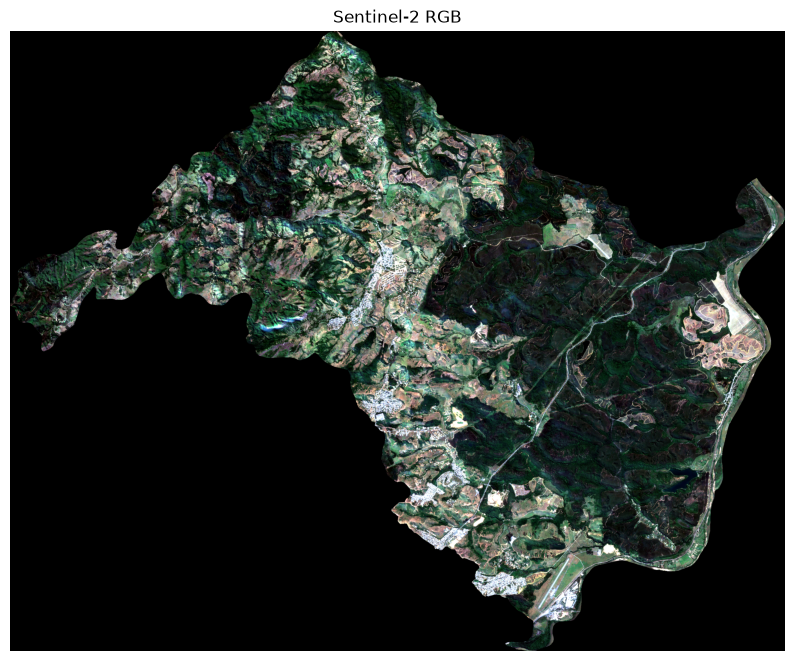

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(file_path) as src:
    rgb = src.read([3, 2, 1]).astype(np.float32)

rgb = np.moveaxis(rgb, 0, -1)

for i in range(3):
    band = rgb[:, :, i]

    valid = np.isfinite(band)

    if np.any(valid):
        p2, p98 = np.percentile(band[valid], (2, 98))

        band = np.clip(band, p2, p98)
        band = (band - p2) / (p98 - p2)

        # Display NaN pixels as black
        band[~valid] = 0

        rgb[:, :, i] = band

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.axis("off")
plt.title("Sentinel-2 RGB")
plt.show()